In [3]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.3/101.7 MB 9.7 MB/s eta 0:00:11
   - -------------------------------------- 4.2/101.7 MB 15.4 MB/s eta 0:00:07
   -- ------------------------------------- 5.5/101.7 MB 10.2 MB/s eta 0:00:10
   -- ------------------------------------- 6.3/101.7 MB 8.4 MB/s eta 0:00:12
   -- ------------------------------------- 7.1/101.7 MB 7.8 MB/s eta 0:00:13
   -- ------------------------------------- 7.6/101.7 MB 6.8 MB/s eta 0:00:14
   --- ------------------------------------ 8.1/101.7 MB 5.9 MB/s eta 0:00:16
   --- ------------------------------------ 8.7/101.7 MB 5.3 MB/s eta 0:00:18
   --- ------------------------------------ 8.9/101.7 MB 4.9 MB/s eta 0:00:19
   --- ------------------------------------ 9.2/101.7 MB 4.7 MB/s eta 0:00:20
   --- ------------------------------------ 9.7/101.7 MB 4.3 MB/s eta 0:00:22
   --- ------------------------------------ 10.0/101.7 MB 4.2 MB/s et

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

In [7]:
#Dataset Link:- https://www.kaggle.com/code/pragathiputhran/calories-burnt-prediction/data

In [5]:
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories.csv")
df.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [6]:
df.shape

(15000, 2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB


In [8]:
df.describe()

,User_ID,Calories
count,1.500000e+04,15000.000000
mean,1.497736e+07,89.539533
std,2.872851e+06,62.456978
min,1.000116e+07,1.000000
25%,1.247419e+07,35.000000
50%,1.499728e+07,79.000000
75%,1.744928e+07,138.000000
max,1.999965e+07,314.000000


In [ ]:
#Exploratory Data Analysis
#EDA is an approach to analyzing the data using visual techniques. 
#It is used to discover trends, and patterns, or
#to check assumptions with the help of statistical summaries and graphical representations.

Columns in dataset: Index(['User_ID', 'Calories'], dtype='object')


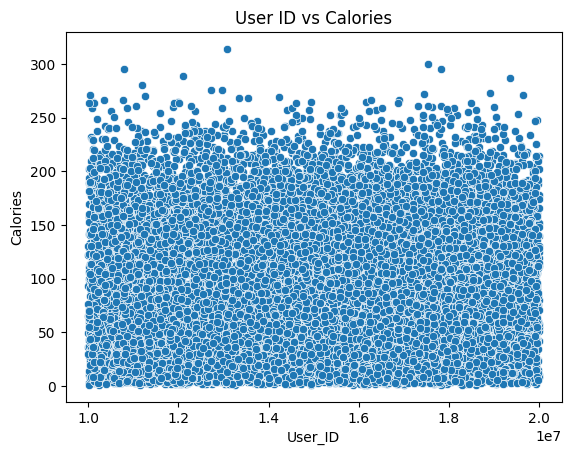

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
# Load dataset
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories.csv")
# Clean column names
df.columns = df.columns.str.strip()
# Print columns to confirm
print("Columns in dataset:", df.columns)
# Scatter Plot (Correct columns)
sb.scatterplot(x='User_ID', y='Calories', data=df)
plt.title("User ID vs Calories")
plt.xlabel("User_ID")
plt.ylabel("Calories")
plt.show()

Columns in dataset: Index(['User_ID', 'Calories'], dtype='object')


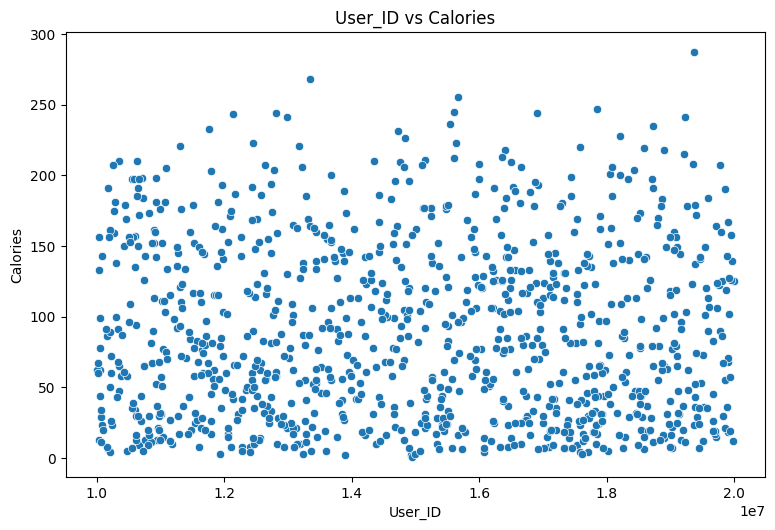

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
# Load dataset
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories.csv")
# Clean column names
df.columns = df.columns.str.strip()
# Print actual columns
print("Columns in dataset:", df.columns)
# Select numeric columns except Calories
features = df.select_dtypes(include=np.number).columns.tolist()
if 'Calories' in features:
    features.remove('Calories')
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    x = df.sample(min(1000, len(df)))
    sb.scatterplot(x=col, y='Calories', data=x)
    plt.title(f"{col} vs Calories")
plt.tight_layout()
plt.show()

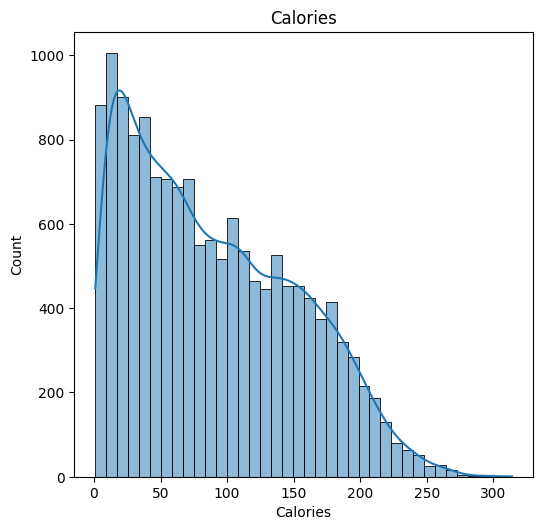

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
# Select only float columns
features = df.select_dtypes(include='float').columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sb.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

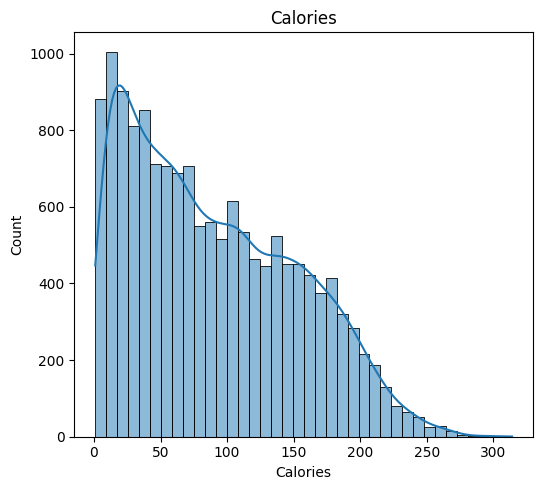

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
# Select float columns
features = df.select_dtypes(include='float').columns
n = len(features)
rows = (n // 3) + (n % 3 > 0)
plt.figure(figsize=(15, 5 * rows))
for i, col in enumerate(features):
    plt.subplot(rows, 3, i + 1)
    sb.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [17]:
df.replace({'male': 0, 'female': 1},
           inplace=True)
df.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


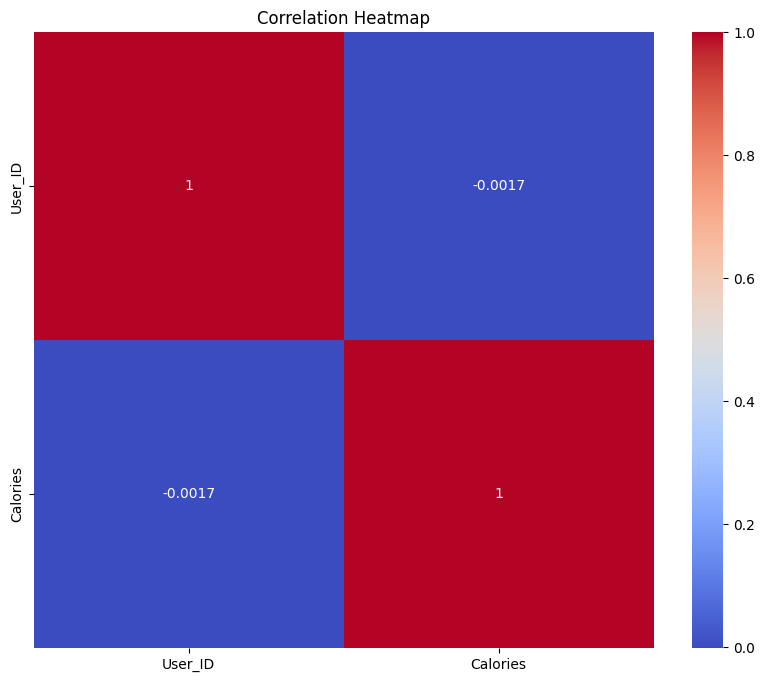

In [20]:
plt.figure(figsize=(10, 8))
sb.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

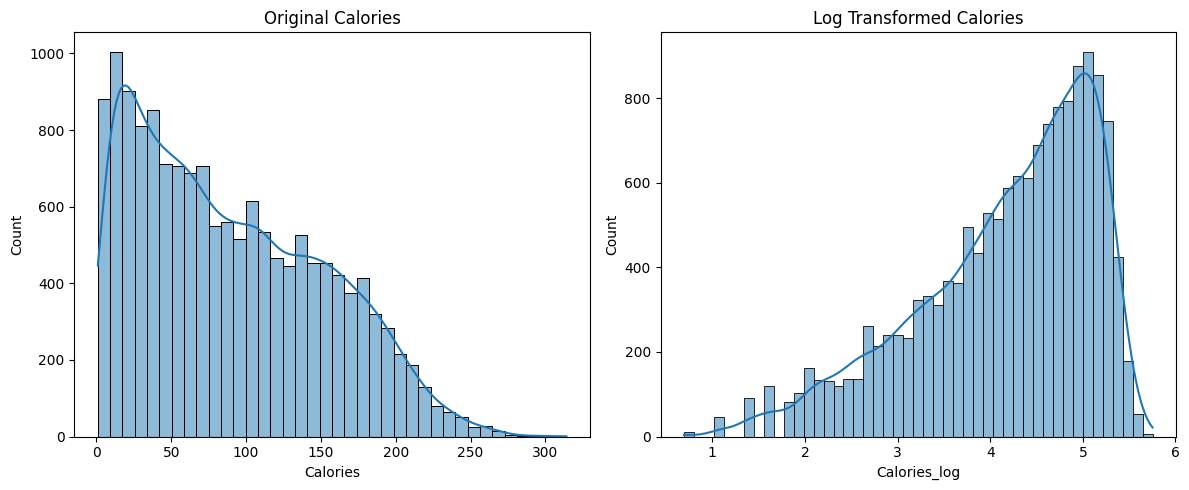

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
# Create new log-transformed column
df['Calories_log'] = np.log1p(df['Calories'])
# Compare Distributions
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sb.histplot(df['Calories'], kde=True)
plt.title("Original Calories")
plt.subplot(1,2,2)
sb.histplot(df['Calories_log'], kde=True)
plt.title("Log Transformed Calories")
plt.tight_layout()
plt.show()

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:

# import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
#from sklearn.linear_model import Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import pickle

import warnings
from warnings import filterwarnings
filterwarnings("ignore")

sns.set()

In [3]:
#Load the Calories dataset
df1 = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")
df1.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [ ]:
#Dataset Link:- https://www.kaggle.com/code/pragathiputhran/calories-burnt-prediction/data

In [4]:
df1.shape

(15000, 2)

In [5]:
#Load the Exercise Dataset
df2 = pd.read_csv(r"C:\Users\KIIT\Downloads\exercise (1).csv")
df2.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [6]:
df2.shape

(15000, 8)

In [7]:
#Now Concatenate both the Dataframe i.e df1 and df2
df = pd.concat([df2,df1["Calories"]],axis=1)
     

In [8]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [10]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [11]:
df.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [12]:
# drop User_ID column because this is not required from Main Dataframe itself
df.drop(columns = ["User_ID"],axis=1,inplace =True)

In [13]:
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      15000 non-null  object 
 1   Age         15000 non-null  int64  
 2   Height      15000 non-null  float64
 3   Weight      15000 non-null  float64
 4   Duration    15000 non-null  float64
 5   Heart_Rate  15000 non-null  float64
 6   Body_Temp   15000 non-null  float64
 7   Calories    15000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 937.6+ KB


In [15]:
#Separate Categorical and Numerical Features
#1. Categorical Feature
#Fatching Categorical Data
cat_col=[col for col in df.columns if df[col].dtype=='O'] #-->Object-"o"
cat_col

['Gender']

In [16]:
df["Gender"].value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

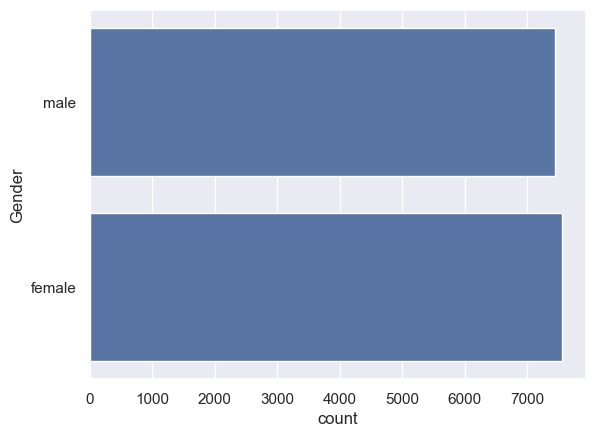

In [17]:
# plotting the gender column in count plot
sns.countplot(df['Gender'])
plt.show()

In [18]:
#pd.get_dummies(df["Gender"],drop_first=True)

In [19]:
categorical = df[cat_col]
categorical.head()
     

,Gender
0,male
1,female
2,male
3,female
4,female


In [20]:
categorical = pd.get_dummies(categorical["Gender"],drop_first=True)
     

In [21]:

categorical
     

,male
0,True
1,False
2,True
3,False
4,False
...,...
14995,False
14996,False
14997,False
14998,True


In [22]:
#2.Numerical Features
Num_col = [col for col in df.columns if df[col].dtype != "O"]
Num_col

['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']

In [23]:

Numerical = df[Num_col]
Numerical.head() 
     

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,69,179.0,79.0,5.0,88.0,38.7,26.0
3,34,179.0,71.0,13.0,100.0,40.5,71.0
4,27,154.0,58.0,10.0,81.0,39.8,35.0


In [24]:
df[Num_col].shape

(15000, 7)

In [25]:
Numerical.shape

(15000, 7)

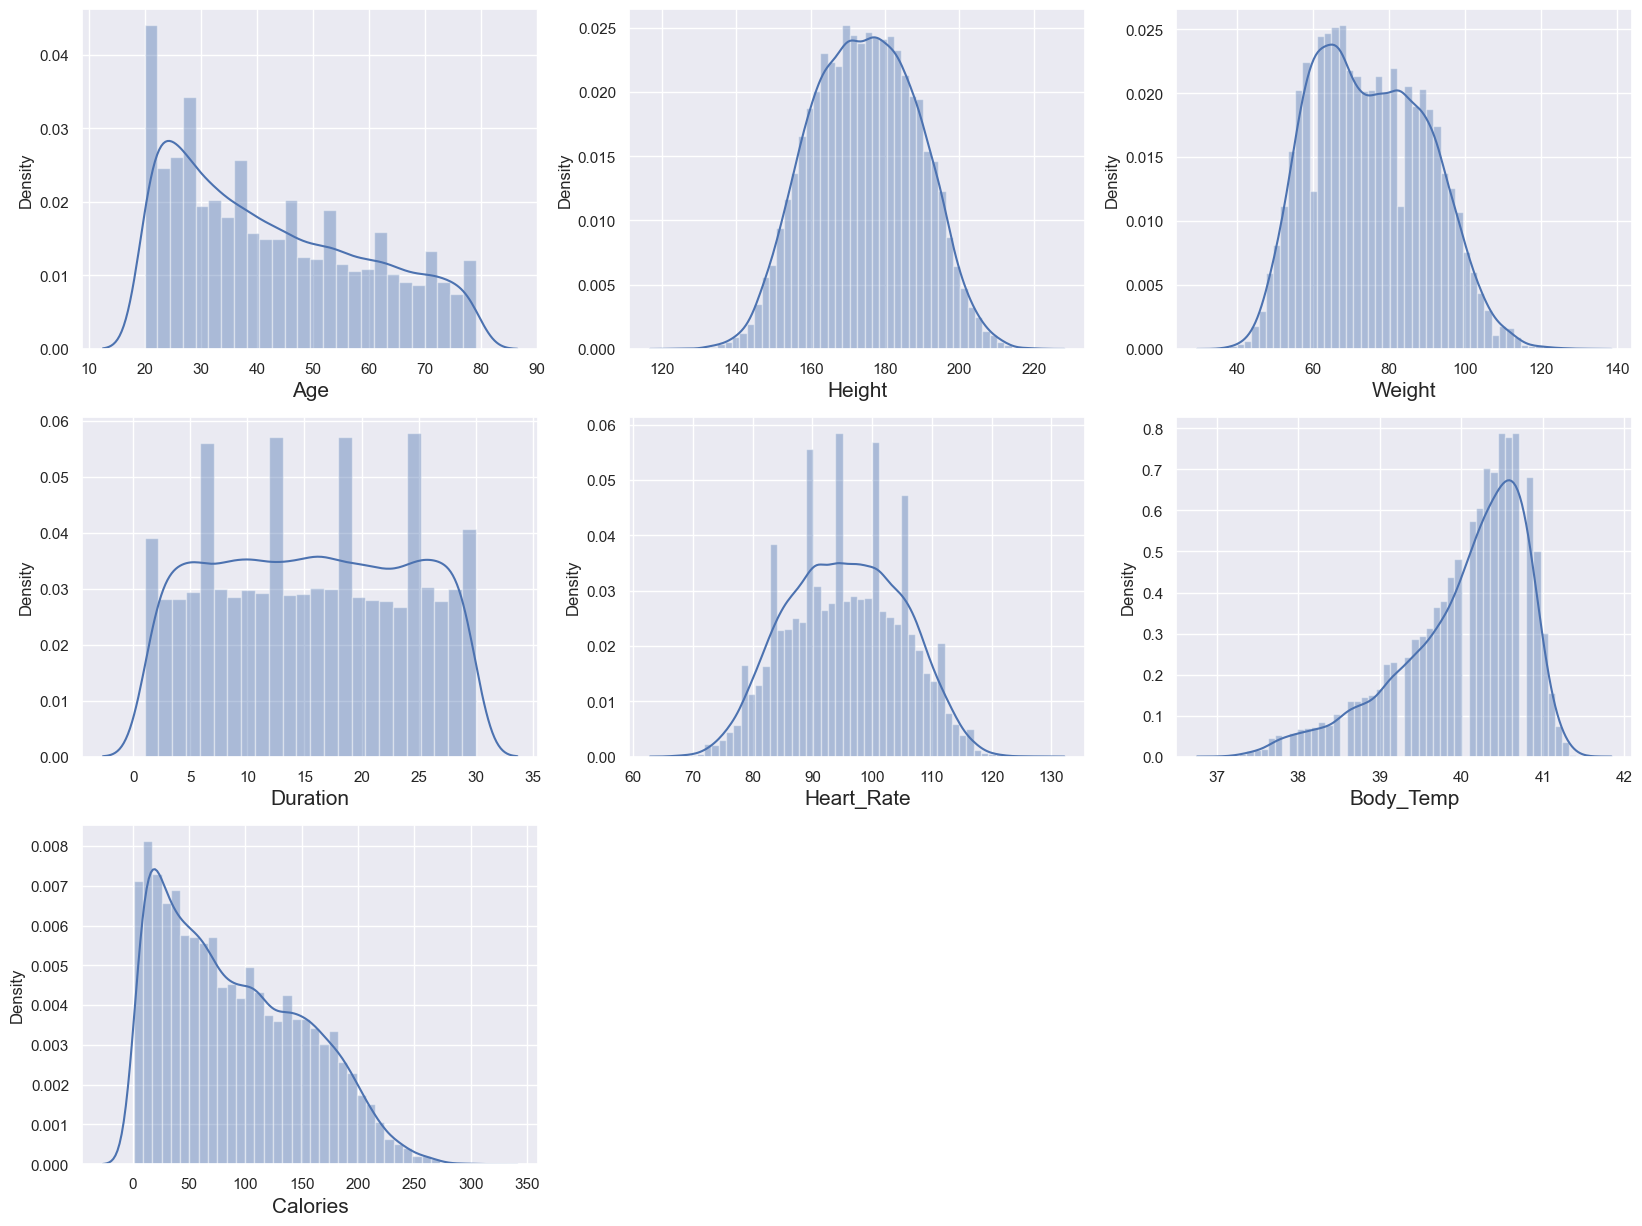

In [26]:
plt.figure(figsize=(20,15))
plotnumber = 1
for column in Numerical:
  if plotnumber <= 8:
    ax = plt.subplot(3,3,plotnumber)
    sns.distplot(Numerical[column])
    plt.xlabel(column,fontsize=15)
  plotnumber+=1
plt.show()
     

<Axes: >

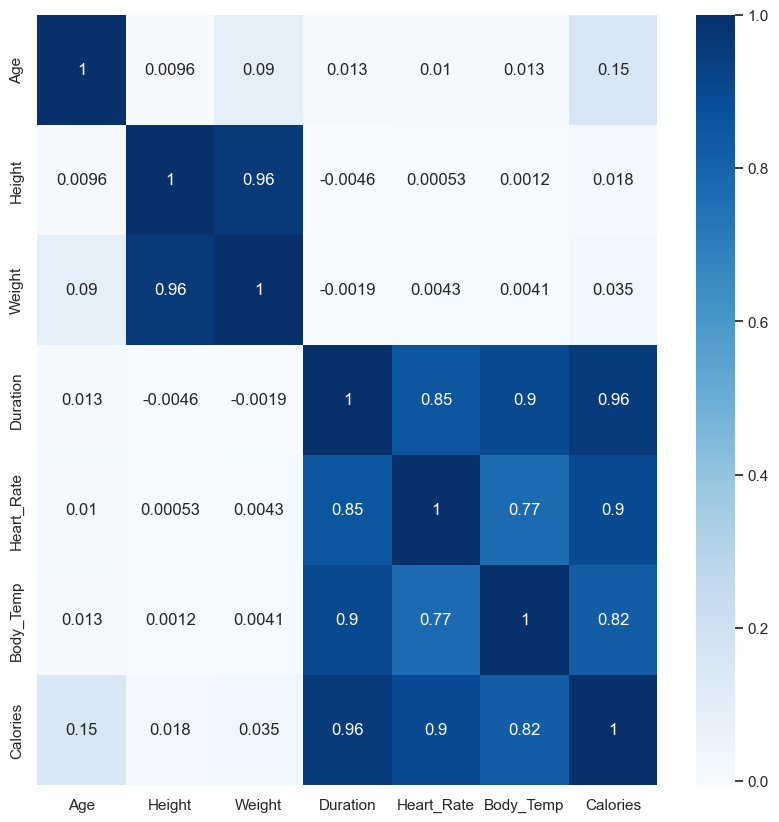

In [27]:
# constructing a heatmap to understand the correlation
plt.figure(figsize=(10,10))
sns.heatmap(Numerical.corr(), cmap='Blues',annot = True)

In [28]:
#Concatenate Categorical and Numerical

data = pd.concat([categorical,Numerical],axis=1)
     


In [29]:

data.head()

,male,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,True,68,190.0,94.0,29.0,105.0,40.8,231.0
1,False,20,166.0,60.0,14.0,94.0,40.3,66.0
2,True,69,179.0,79.0,5.0,88.0,38.7,26.0
3,False,34,179.0,71.0,13.0,100.0,40.5,71.0
4,False,27,154.0,58.0,10.0,81.0,39.8,35.0


<Axes: >

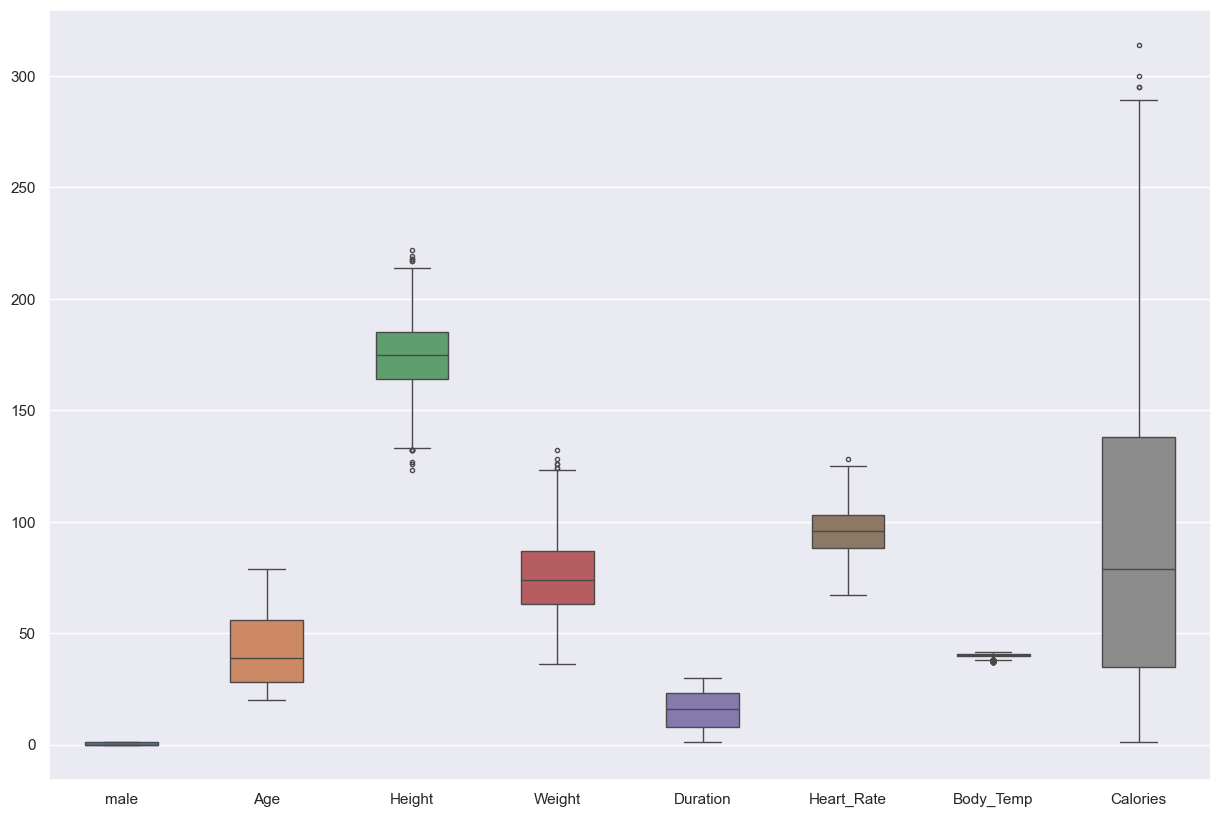

In [30]:

fig,ax = plt.subplots(figsize = (15,10))
sns.boxplot(data=data,width = 0.5,fliersize = 3,ax=ax)
     

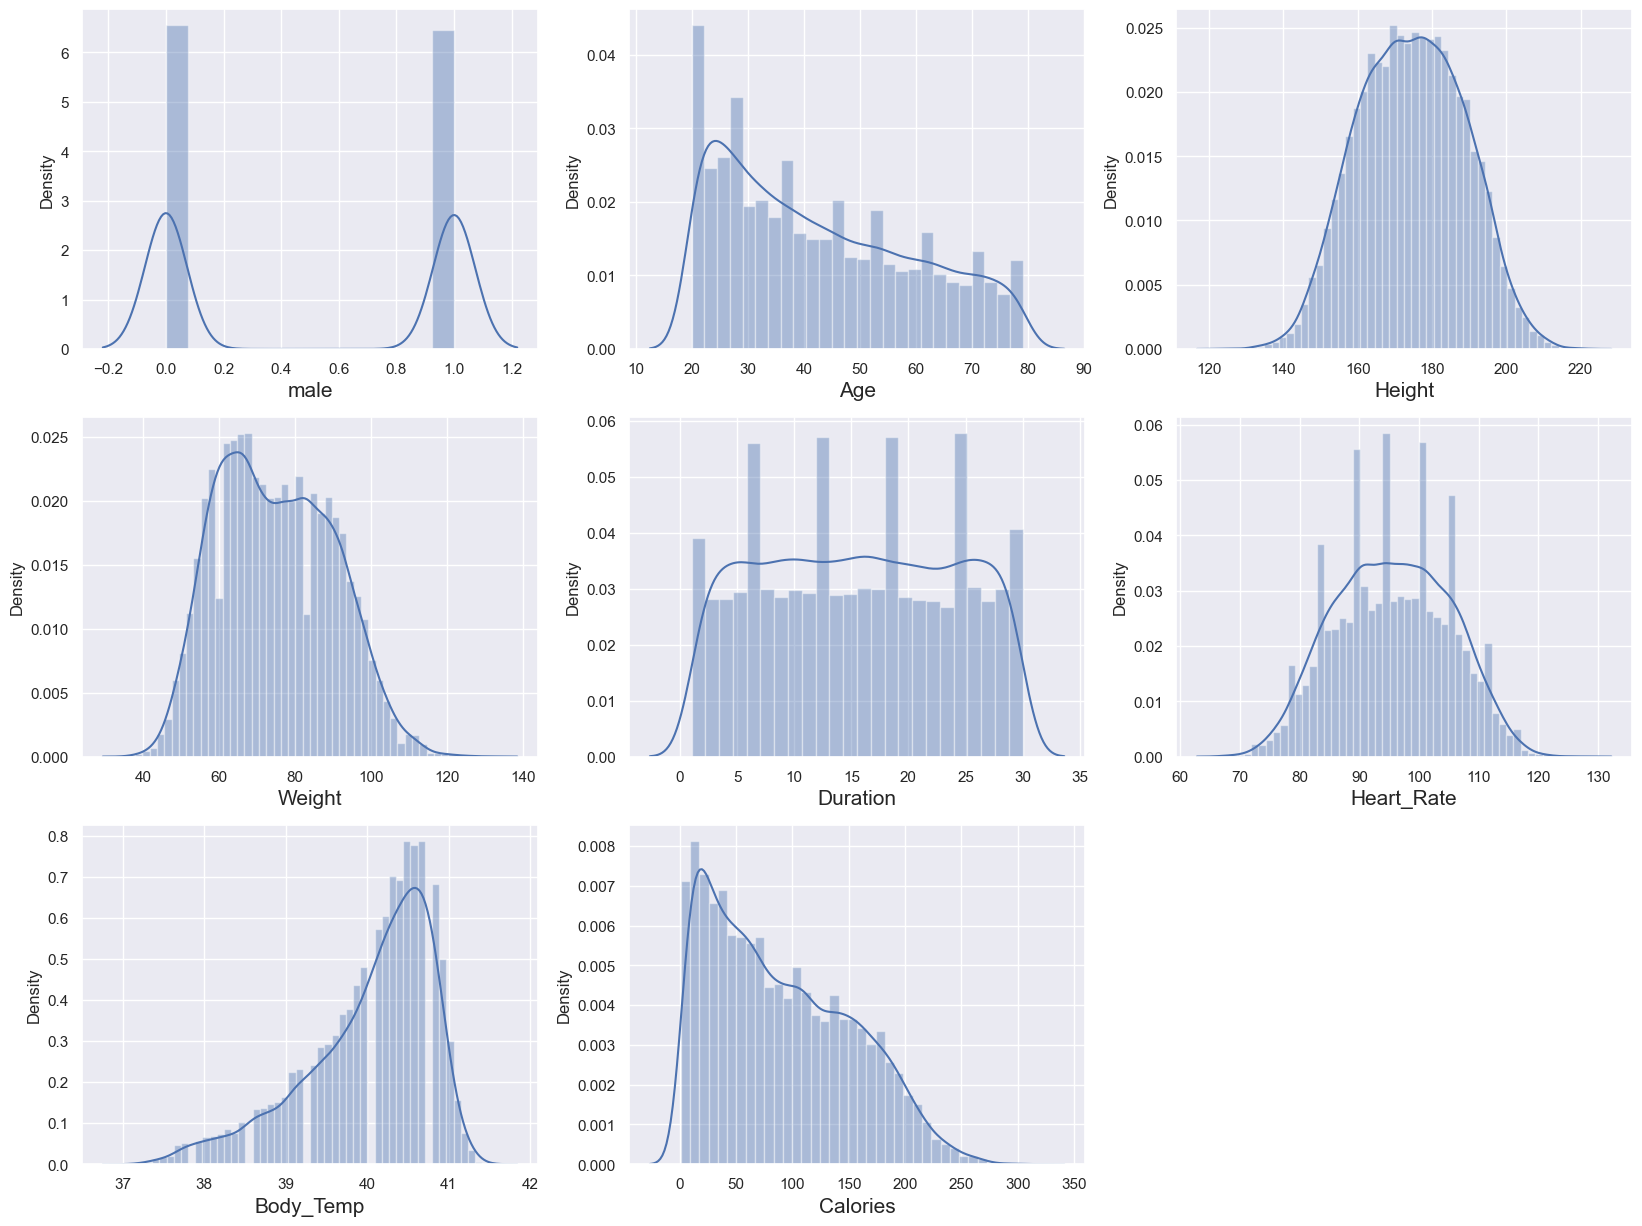

In [31]:

plt.figure(figsize=(20,15))
plotnumber = 1

for column in data:
  if plotnumber <= 8:
    ax = plt.subplot(3,3,plotnumber)
    sns.distplot(data[column])
    plt.xlabel(column,fontsize=15)
  plotnumber+=1
plt.show()

In [32]:
data.columns

Index(['male', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp', 'Calories'],
      dtype='object')

In [44]:


X = data.drop(columns = ["Calories"],axis = 1)
y = data["Calories"]
     

In [45]:
X.head()
     

,male,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,True,68,190.0,94.0,29.0,105.0,40.8
1,False,20,166.0,60.0,14.0,94.0,40.3
2,True,69,179.0,79.0,5.0,88.0,38.7
3,False,34,179.0,71.0,13.0,100.0,40.5
4,False,27,154.0,58.0,10.0,81.0,39.8


In [46]:

y.head()

0    231.0
1     66.0
2     26.0
3     71.0
4     35.0
Name: Calories, dtype: float64

In [47]:

# Split the Data

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=1)

In [48]:

print("Shape of X Train: ",X_train.shape)
print("Shape of X Test: ",X_test.shape)
print("Shape of y Train: ",y_train.shape)
print("Shape of y Test: ",y_test.shape)

Shape of X Train:  (12000, 7)
Shape of X Test:  (3000, 7)
Shape of y Train:  (12000,)
Shape of y Test:  (3000,)


In [49]:
#from sklearn import metrics
def predict(ml_model):
    model=ml_model.fit(X_train,y_train)
    print('Score : {}'.format(model.score(X_train,y_train)))
    y_prediction=model.predict(X_test)
    print('predictions are: \n {}'.format(y_prediction))
    print('\n')

    r2_score=metrics.r2_score(y_test,y_prediction)
    print('r2 score: {}'.format(r2_score))

    print('MAE:',metrics.mean_absolute_error(y_test,y_prediction))
    print('MSE:',metrics.mean_squared_error(y_test,y_prediction))
    print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test,y_prediction)))
    
    sns.distplot(y_test-y_prediction)
     

Score : 0.9995380557081355
predictions are: 
 [197.06581   70.867226 196.99498  ...  29.043041 104.09284   14.61472 ]


r2 score: 0.9986863132331905
MAE: 1.5521575984954834
MSE: 5.2744122853837005
RMSE: 2.2966088664340956


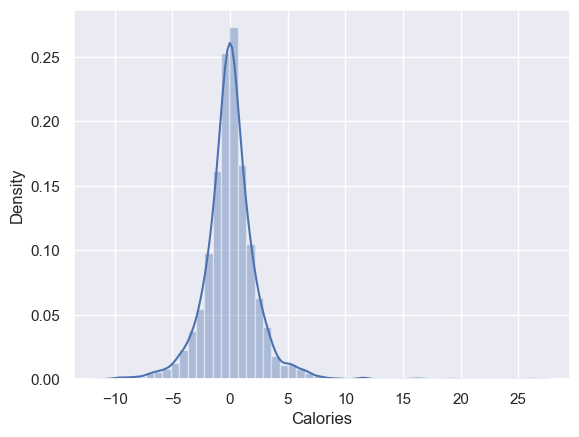

In [50]:
#XGB Regressor
regression = predict(XGBRegressor())
regression

In [51]:
#Save the Model
# saving the model to the local file system
filename = 'finalized_model.pickle'
pickle.dump(regression, open(filename, 'wb'))

In [7]:
def predict(model, name="Model"):
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    print(f"{name}")
    print("Train R2:", r2_score(y_train, y_train_pred))
    print("Test  R2:", r2_score(y_test, y_test_pred))
    print("-" * 30)
    
    return y_test_pred

In [17]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# ==============================
# 2. Load Dataset
# ==============================
data = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")

# Preview dataset
print("Dataset Preview:")
print(data.head())

# ==============================
# 3. Preprocessing
# ==============================
# 🔴 IMPORTANT: Change target column if needed
# Common guess: "Calories"
target_column = "Calories"

X = data.drop(target_column, axis=1)
y = data[target_column]

# Handle missing values
X = X.fillna(X.mean(numeric_only=True))

# Convert categorical columns
X = pd.get_dummies(X, drop_first=True)

# ==============================
# 4. Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 5. Evaluation Function
# ==============================
def evaluate_model(model, name="Model"):
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"{name}")
    print("Train R2:", round(train_r2, 4))
    print("Test  R2:", round(test_r2, 4))
    
    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print("CV R2 (mean):", round(cv_scores.mean(), 4))
    
    print("-" * 40)
    
    return train_r2, test_r2, cv_scores.mean()

# ==============================
# 6. Define Models
# ==============================
models = [
    (LinearRegression(), "Linear Regression"),
    (DecisionTreeRegressor(max_depth=5, random_state=42), "Decision Tree"),
    (RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest")
]

# ==============================
# 7. Train & Evaluate
# ==============================
results = []

for model, name in models:
    train_r2, test_r2, cv_r2 = evaluate_model(model, name)
    results.append([name, train_r2, test_r2, cv_r2])

# ==============================
# 8. Results Table
# ==============================
results_df = pd.DataFrame(results, columns=["Model", "Train R2", "Test R2", "CV R2"])
results_df = results_df.sort_values(by="Test R2", ascending=False)

print("\nModel Comparison:")
print(results_df)

# ==============================
# 9. Best Model
# ==============================
best_model_name = results_df.iloc[0]["Model"]
best_score = results_df.iloc[0]["Test R2"]

print("\nBest Model:", best_model_name)
print("Best Test R2:", round(best_score, 4))

Dataset Preview:
    User_ID  Calories
0  14733363     231.0
1  14861698      66.0
2  11179863      26.0
3  16180408      71.0
4  17771927      35.0
Linear Regression
Train R2: 0.0
Test  R2: -0.0014
CV R2 (mean): -0.0005
----------------------------------------
Decision Tree
Train R2: 0.0085
Test  R2: -0.005
CV R2 (mean): -0.0061
----------------------------------------
Random Forest
Train R2: 0.7978
Test  R2: -0.4993
CV R2 (mean): -0.4611
----------------------------------------

Model Comparison:
               Model  Train R2   Test R2     CV R2
0  Linear Regression  0.000017 -0.001432 -0.000465
1      Decision Tree  0.008478 -0.005033 -0.006089
2      Random Forest  0.797750 -0.499284 -0.461099

Best Model: Linear Regression
Best Test R2: -0.0014


In [18]:
#Random Forest Regression
predict(RandomForestRegressor())

Model
Train R2: 0.7987275338558006
Test  R2: -0.48514558518977213
------------------------------


array([ 64.47, 103.65,  85.75, ..., 132.95,  68.44,  93.93], shape=(3000,))

In [19]:
#DecisionTree Regression
predict(DecisionTreeRegressor())

Model
Train R2: 0.9995966803342309
Test  R2: -0.9985459593986397
------------------------------


array([ 45., 158.,  65., ..., 165.,  76., 102.], shape=(3000,))

In [20]:
#LinearTree Regression
predict(LinearRegression())

Model
Train R2: 1.687921619886179e-05
Test  R2: -0.0014323927992658803
------------------------------


array([88.88007981, 89.00861006, 89.29561652, ..., 88.76704907,
       89.49994823, 89.38819961], shape=(3000,))

In [21]:
#RandomTree Regression
predict(RandomForestRegressor())

Model
Train R2: 0.7995644622532037
Test  R2: -0.4954155022757665
------------------------------


array([ 72.23, 121.26,  83.69, ..., 123.93,  62.14,  86.49], shape=(3000,))

In [23]:
#from sklearn import metrics
def predict(ml_model):
    model=ml_model.fit(X_train,y_train)
    print('Score : {}'.format(model.score(X_train,y_train)))
    y_prediction=model.predict(X_test)
    print('predictions are: \n {}'.format(y_prediction))
    print('\n')

    r2_score=metrics.r2_score(y_test,y_prediction)
    print('r2 score: {}'.format(r2_score))

    print('MAE:',metrics.mean_absolute_error(y_test,y_prediction))
    print('MSE:',metrics.mean_squared_error(y_test,y_prediction))
    print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test,y_prediction)))
    
    sns.distplot(y_test-y_prediction)
     

In [25]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [1]:
#from sklearn import metrics
def predict(ml_model):
    model=ml_model.fit(X_train,y_train)
    print('Score : {}'.format(model.score(X_train,y_train)))
    y_prediction=model.predict(X_test)
    print('predictions are: \n {}'.format(y_prediction))
    print('\n')

    r2_score=metrics.r2_score(y_test,y_prediction)
    print('r2 score: {}'.format(r2_score))

    print('MAE:',metrics.mean_absolute_error(y_test,y_prediction))
    print('MSE:',metrics.mean_squared_error(y_test,y_prediction))
    print('RMSE:',np.sqrt(metrics.mean_squared_error(y_test,y_prediction)))
    
    sns.distplot(y_test-y_prediction)

 Dataset Loaded Successfully!

First 5 rows:
    User_ID  Calories
0  14733363     231.0
1  14861698      66.0
2  11179863      26.0
3  16180408      71.0
4  17771927      35.0

Train Shape: (12000, 1)
Test Shape: (3000, 1)

 Model Performance:
R2 Score : -0.0191
MSE      : 4112.7453
MAE      : 54.3525

 Top 10 Important Features:
   Feature  Importance
0  User_ID         1.0


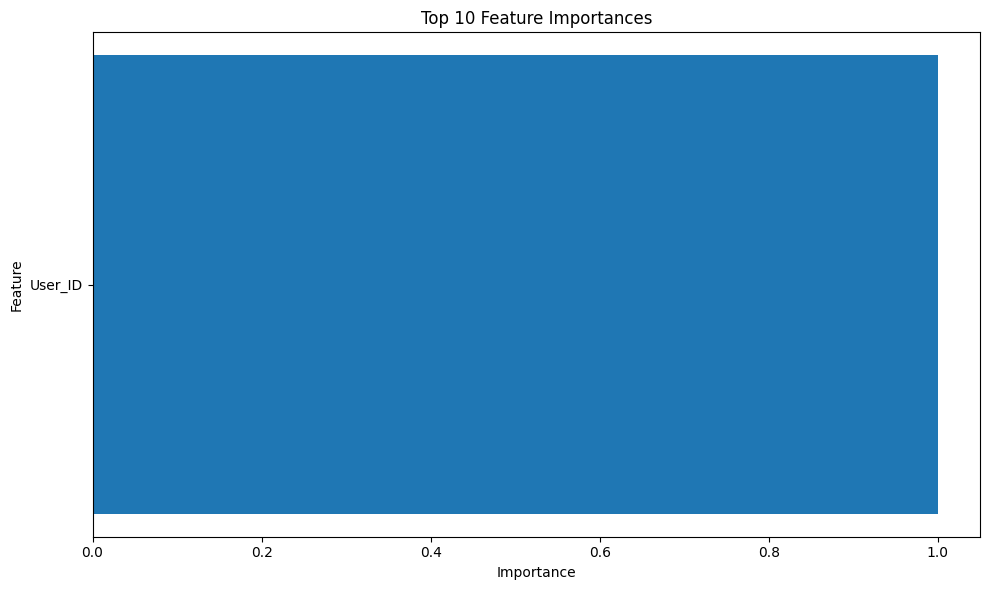

In [6]:
# ================================
# Step 0: Install (run once)
# ================================
# !pip install xgboost pandas scikit-learn matplotlib

# ================================
# Step 1: Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ================================
# Step 2: Load Dataset
# ================================
file_path =  r"C:\Users\KIIT\Downloads\calories (2).csv" # <-- CHANGE if needed

try:
    data = pd.read_csv(file_path)
    print(" Dataset Loaded Successfully!\n")
except Exception as e:
    print(" Error loading file:", e)
    exit()

print("First 5 rows:")
print(data.head())

# ================================
# Step 3: Define Features & Target
# ================================
target_column = "Calories"  # <-- CHANGE if needed

if target_column not in data.columns:
    raise ValueError(f"Target column '{target_column}' not found in dataset!")

X = data.drop(columns=[target_column])
y = data[target_column]

# ================================
# Step 4: Handle Categorical Data
# ================================
X = pd.get_dummies(X, drop_first=True)

# ================================
# Step 5: Handle Missing Values
# ================================
X = X.fillna(X.mean())  # Better than 0

# ================================
# Step 6: Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# ================================
# Step 7: Initialize Model
# ================================
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# ================================
# Step 8: Train Model
# ================================
model.fit(X_train, y_train)

# ================================
# Step 9: Predictions
# ================================
y_pred = model.predict(X_test)

# ================================
# Step 10: Evaluation
# ================================
print("\n Model Performance:")
print("R2 Score :", round(r2_score(y_test, y_pred), 4))
print("MSE      :", round(mean_squared_error(y_test, y_pred), 4))
print("MAE      :", round(mean_absolute_error(y_test, y_pred), 4))

# ================================
# Step 11: Feature Importance
# ================================
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n Top 10 Important Features:")
print(importance_df.head(10))

# Plot Top 10 Features
plt.figure(figsize=(10, 6))
top_features = importance_df.head(10)

plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")
df.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [10]:
df.shape

(15000, 2)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User_ID   15000 non-null  int64  
 1   Calories  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 234.5 KB


In [12]:
df.describe()

,User_ID,Calories
count,1.500000e+04,15000.000000
mean,1.497736e+07,89.539533
std,2.872851e+06,62.456978
min,1.000116e+07,1.000000
25%,1.247419e+07,35.000000
50%,1.499728e+07,79.000000
75%,1.744928e+07,138.000000
max,1.999965e+07,314.000000


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

# Load dataset
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Columns in dataset:", df.columns.tolist())

# Safe check
height_cols = [col for col in df.columns if 'height' in col.lower()]
weight_cols = [col for col in df.columns if 'weight' in col.lower()]

if len(height_cols) == 0 or len(weight_cols) == 0:
    print("\n❌ Height/Weight columns not found!")
    print("👉 Please check column names above and update manually.")
else:
    height_col = height_cols[0]
    weight_col = weight_cols[0]

    sb.scatterplot(x=height_col, y=weight_col, data=df)
    plt.title("Height vs Weight")
    plt.show()

Columns in dataset: ['User_ID', 'Calories']

❌ Height/Weight columns not found!
👉 Please check column names above and update manually.


In [23]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error as mae

# Define models with names
models = {
    "Linear Regression": LinearRegression(),
    "XGBoost": XGBRegressor(),
    "Lasso": Lasso(),
    "Random Forest": RandomForestRegressor(),
    "Ridge": Ridge()
}

# Train & evaluate
for name, model in models.items():
    model.fit(X_train, y_train)

    print(f"===== {name} =====")

    # Training error
    train_preds = model.predict(X_train)
    print("Training MAE:", mae(y_train, train_preds))

    # Validation/Test error
    val_preds = model.predict(X_test)   # use X_test if no validation set
    print("Validation MAE:", mae(y_test, val_preds))

    print()

===== Linear Regression =====
Training MAE: 52.86809436578614
Validation MAE: 53.93364822763257

===== XGBoost =====
Training MAE: 52.1086100063324
Validation MAE: 54.40185835520426

===== Lasso =====
Training MAE: 52.86809436806662
Validation MAE: 53.93364821938889

===== Random Forest =====
Training MAE: 22.495927099206348
Validation MAE: 62.98720905555556

===== Ridge =====
Training MAE: 52.86809436578614
Validation MAE: 53.93364822763257



In [25]:
from sklearn.model_selection import train_test_split

# First split (Train + Temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split (Validation + Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [26]:
# Normalizing the features for stable and fast training.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [27]:
features = df.drop(['User_ID', 'Calories'], axis=1)
target = df['Calories'].values

X_train, X_val,\
    Y_train, Y_val = train_test_split(features, target,
                                      test_size=0.1,
                                      random_state=22)
X_train.shape, X_val.shape

((13500, 0), (1500, 0))

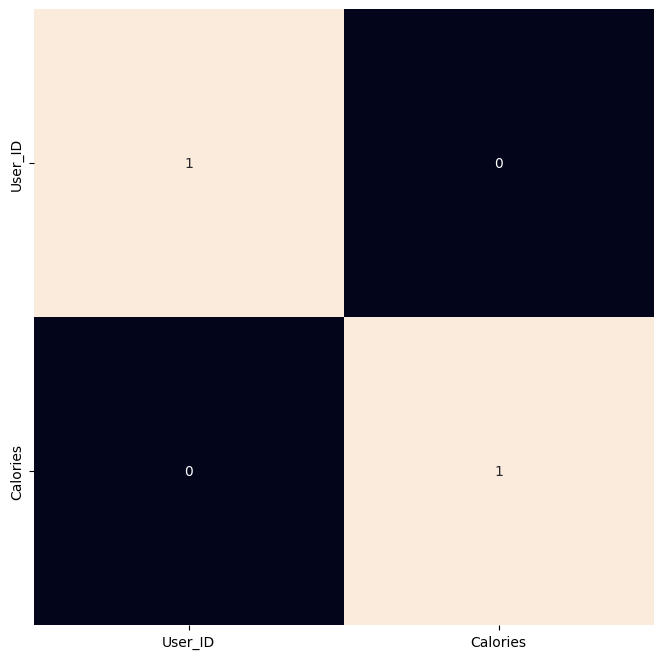

In [29]:
plt.figure(figsize=(8, 8))
sb.heatmap(df.corr() > 0.9,
           annot=True,
           cbar=False)
plt.show()

In [30]:
df.replace({'male': 0, 'female': 1},
           inplace=True)
df.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


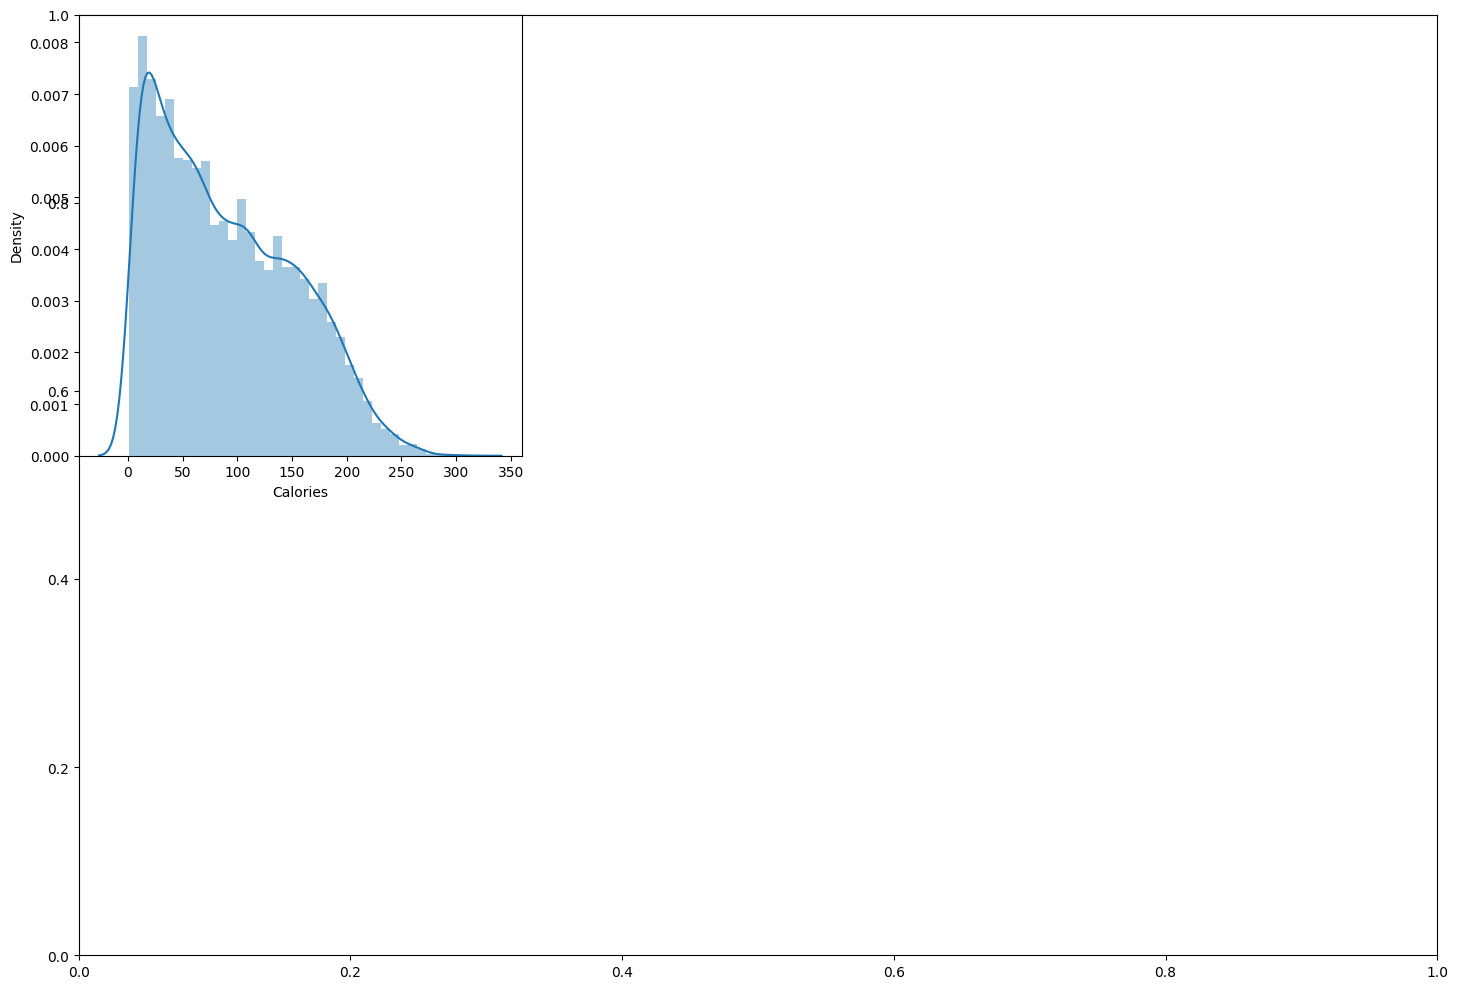

In [31]:
features = df.select_dtypes(include='float').columns
plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    sb.distplot(df[col])
plt.tight_layout()
plt.show()

Columns: ['user_id', 'calories']


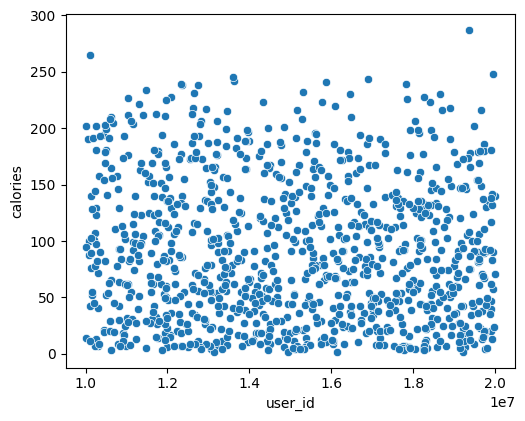

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

# Load
df = pd.read_csv(r"C:\Users\KIIT\Downloads\calories (2).csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Columns:", df.columns.tolist())

# ---- Auto-detect target (calories) ----
cal_cols = [c for c in df.columns if 'cal' in c]
if not cal_cols:
    raise ValueError("No 'calories' column found. Check printed columns.")
target = cal_cols[0]

# ---- Auto-detect numeric feature columns ----
num_cols = df.select_dtypes(include='number').columns.tolist()

# Remove target from features
features = [c for c in num_cols if c != target]

if not features:
    raise ValueError("No numeric features found to plot.")

# Pick up to 4 features
features = features[:4]

# ---- Plot safely ----
plt.figure(figsize=(10, 8))

sample_df = df.sample(min(1000, len(df)), random_state=42)

for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sb.scatterplot(x=col, y=target, data=sample_df)
    plt.xlabel(col)
    plt.ylabel(target)

plt.tight_layout()
plt.show()